# 구내식당 식수 인원 예측 모델

이 노트북은 DACON '구내식당 식수 인원 예측 AI 경진대회' 데이터를 사용하여, 중식계와 석식계를 예측하는 시계열 프로젝트입니다.
EDA, 전처리, 모델 생성(LightGBM 사용), 학습 및 평가 과정을 포함하고 있습니다.

## 1. 라이브러리 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정 (korean_font.py 로드)
import sys
import os
sys.path.append(os.path.abspath('.'))
from korean_font import set_korean_font
set_korean_font()

# matplotlib 기본 설정
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지
sns.set_palette("Set2")

한글 폰트 설정: Malgun Gothic (c:/Windows/Fonts/malgun.ttf)


In [2]:
# 데이터 로드
train = pd.read_csv('data/train.csv')
test = pd.read_csv('data/test.csv')
submission = pd.read_csv('data/sample_submission.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
display(train.head(3))

Train shape: (1205, 12)
Test shape: (50, 10)


,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,조식메뉴,중식메뉴,석식메뉴,중식계,석식계
0,2016-02-01,월,2601,50,150,238,0.0,모닝롤/찐빵 우유/두유/주스 계란후라이 호두죽/쌀밥 (쌀:국내산) 된장찌개 쥐...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 오징어찌개 쇠불고기 (쇠고기:호주산) 계란찜 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 육개장 자반고등어구이 두부조림 건파래무침 ...",1039.0,331.0
1,2016-02-02,화,2601,50,173,319,0.0,모닝롤/단호박샌드 우유/두유/주스 계란후라이 팥죽/쌀밥 (쌀:국내산) 호박젓국찌...,"쌀밥/잡곡밥 (쌀,현미흑미:국내산) 김치찌개 가자미튀김 모둠소세지구이 마늘쫑무...","콩나물밥*양념장 (쌀,현미흑미:국내산) 어묵국 유산슬 (쇠고기:호주산) 아삭고추무...",867.0,560.0
2,2016-02-03,수,2601,56,180,111,0.0,모닝롤/베이글 우유/두유/주스 계란후라이 표고버섯죽/쌀밥 (쌀:국내산) 콩나물국...,"카레덮밥 (쌀,현미흑미:국내산) 팽이장국 치킨핑거 (닭고기:국내산) 쫄면야채무침 ...","쌀밥/잡곡밥 (쌀,현미흑미:국내산) 청국장찌개 황태양념구이 (황태:러시아산) 고기...",1017.0,573.0


In [12]:
train.describe()

,일자,요일,본사정원수,본사휴가자수,본사출장자수,본사시간외근무명령서승인건수,현본사소속재택근무자수,중식계,석식계,년,월,일,식사가능인원
count,1205,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000,1205.000000
mean,2018-07-21 00:56:09.958506,2.003320,2807.815768,157.913693,241.142739,274.117012,43.506224,890.334440,461.772614,2018.052282,6.512033,15.947718,2365.253112
min,2016-02-01 00:00:00,0.000000,2601.000000,23.000000,41.000000,0.000000,0.000000,296.000000,0.000000,2016.000000,1.000000,1.000000,1372.000000
25%,2017-04-19 00:00:00,1.000000,2645.000000,71.000000,217.000000,4.000000,0.000000,758.000000,406.000000,2017.000000,4.000000,9.000000,2281.000000
50%,2018-07-16 00:00:00,2.000000,2760.000000,105.000000,245.000000,299.000000,0.000000,879.000000,483.000000,2018.000000,7.000000,16.000000,2357.000000
75%,2019-10-17 00:00:00,3.000000,2962.000000,185.000000,272.000000,452.000000,0.000000,1032.000000,545.000000,2019.000000,9.000000,23.000000,2461.000000
max,2021-01-26 00:00:00,4.000000,3305.000000,1224.000000,378.000000,1044.000000,533.000000,1459.000000,905.000000,2021.000000,12.000000,31.000000,2921.000000
std,NaN,1.415384,171.264404,144.190572,43.532298,246.239651,109.937400,209.505057,139.179202,1.433958,3.453906,8.650452,176.563062


In [13]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1205 entries, 0 to 1204
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   일자              1205 non-null   datetime64[us]
 1   요일              1205 non-null   int64         
 2   본사정원수           1205 non-null   int64         
 3   본사휴가자수          1205 non-null   int64         
 4   본사출장자수          1205 non-null   int64         
 5   본사시간외근무명령서승인건수  1205 non-null   int64         
 6   현본사소속재택근무자수     1205 non-null   float64       
 7   조식메뉴            1205 non-null   str           
 8   중식메뉴            1205 non-null   str           
 9   석식메뉴            1205 non-null   str           
 10  중식계             1205 non-null   float64       
 11  석식계             1205 non-null   float64       
 12  년               1205 non-null   int32         
 13  월               1205 non-null   int32         
 14  일               1205 non-null   int32         
 15  식사가능인원         

## 2. EDA (탐색적 데이터 분석)

### 2.1. 중식계, 석식계 분포 확인

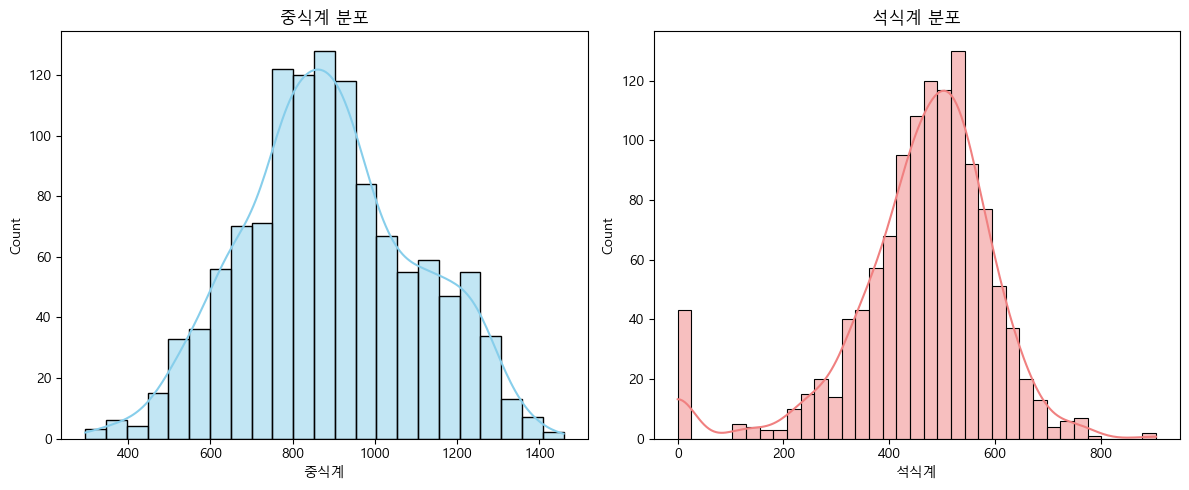

석식계가 0인 일수: 43


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(train['중식계'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('중식계 분포')

sns.histplot(train['석식계'], kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('석식계 분포')
plt.tight_layout()
plt.show()

print("석식계가 0인 일수:", (train['석식계'] == 0).sum())

석식이 제공되지 않은 날(석식계=0)이 존재합니다. 이는 매월 마주하는 행사나 특정 휴무일일 수 있습니다.

### 2.2. 요일별 분석

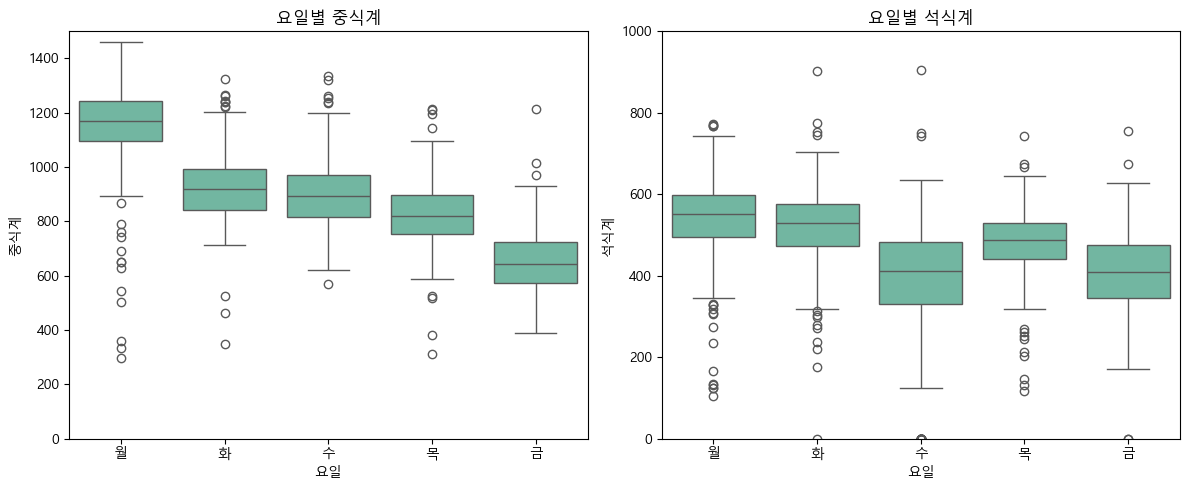

In [4]:
# 요일 순서 지정
day_order = ['월', '화', '수', '목', '금']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='요일', y='중식계', data=train, order=day_order, ax=axes[0])
axes[0].set_title('요일별 중식계')
axes[0].set_ylim(0, 1500)

sns.boxplot(x='요일', y='석식계', data=train, order=day_order, ax=axes[1])
axes[1].set_title('요일별 석식계')
axes[1].set_ylim(0, 1000)
plt.tight_layout()
plt.show()

월요일에 중식이 가장 많고 금요일로 갈수록 감소하는 경향이 있습니다. 석식의 경우 수요일에 매우 적은 날들이 관찰됩니다(가정의 날 예상).

### 2.3. 날짜 관련 시계열 분석

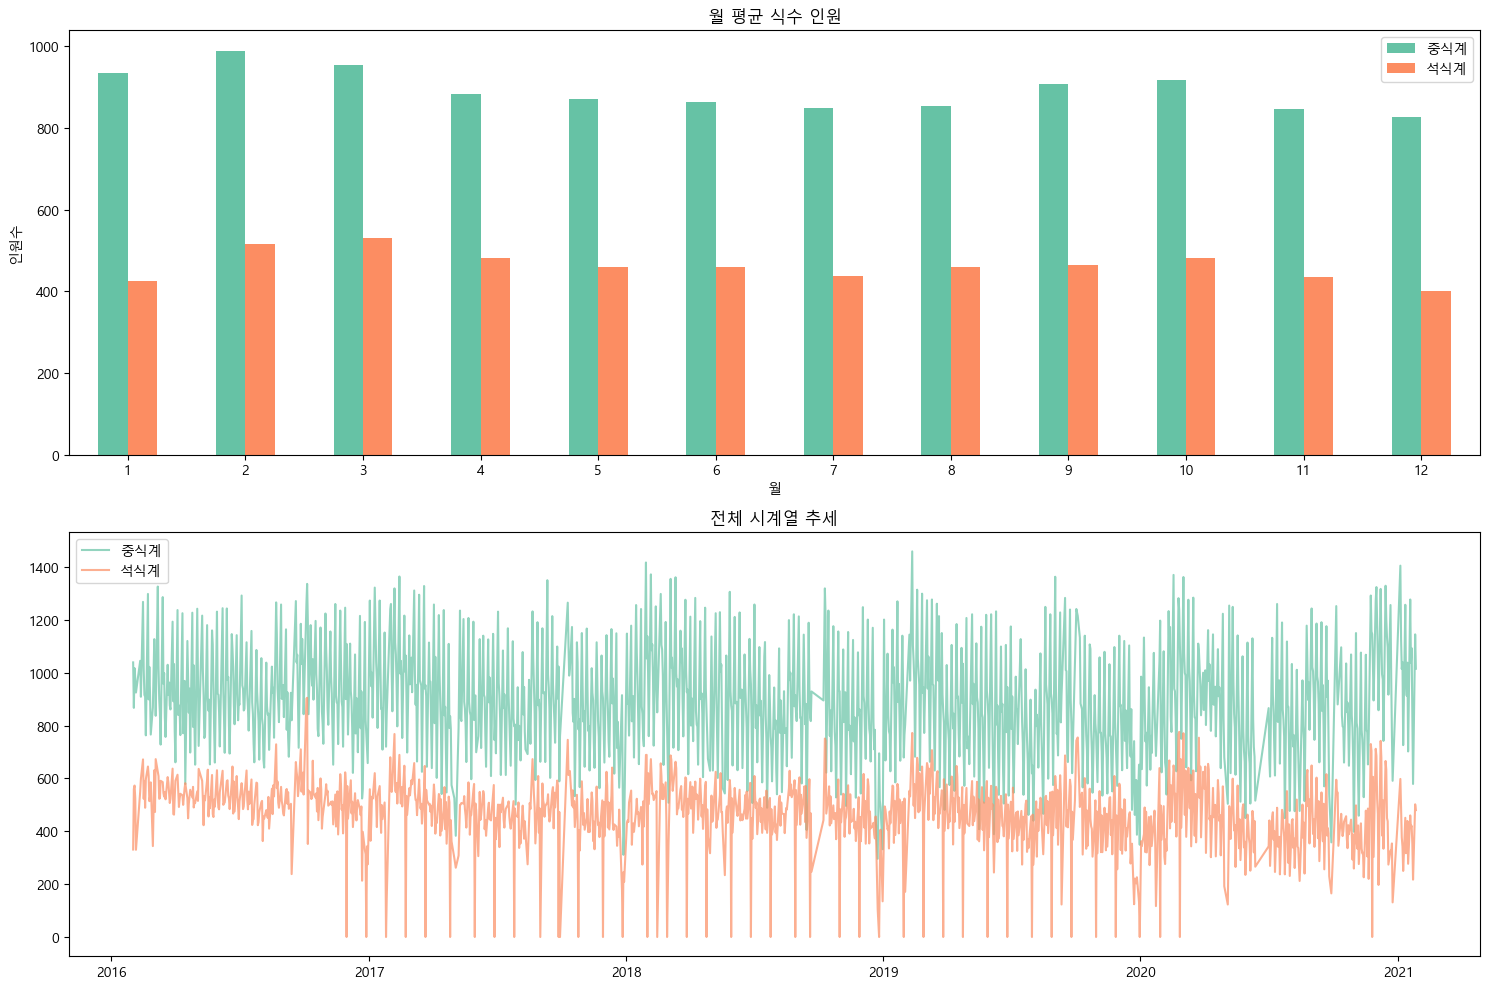

In [5]:
train['일자'] = pd.to_datetime(train['일자'])
test['일자'] = pd.to_datetime(test['일자'])

train['년'] = train['일자'].dt.year
train['월'] = train['일자'].dt.month
train['일'] = train['일자'].dt.day

test['년'] = test['일자'].dt.year
test['월'] = test['일자'].dt.month
test['일'] = test['일자'].dt.day

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
train.groupby('월')[['중식계', '석식계']].mean().plot(kind='bar', ax=axes[0])
axes[0].set_title('월 평균 식수 인원')
axes[0].set_ylabel('인원수')
axes[0].tick_params(axis='x', rotation=0)

# 시계열 추세
axes[1].plot(train['일자'], train['중식계'], label='중식계', alpha=0.7)
axes[1].plot(train['일자'], train['석식계'], label='석식계', alpha=0.7)
axes[1].set_title('전체 시계열 추세')
axes[1].legend()
plt.tight_layout()
plt.show()

## 3. 데이터 전처리 (Feature Engineering)

In [6]:
# 식사 가능 인원 (출근 인원) 파생 변수 생성
# 본사정원수 - 휴가자 - 출장자 - 재택근무자
train['식사가능인원'] = train['본사정원수'] - train['본사휴가자수'] - train['본사출장자수'] - train['현본사소속재택근무자수']
test['식사가능인원'] = test['본사정원수'] - test['본사휴가자수'] - test['본사출장자수'] - test['현본사소속재택근무자수']

print("Train 변수 추가 완료:", train.columns.tolist())

Train 변수 추가 완료: ['일자', '요일', '본사정원수', '본사휴가자수', '본사출장자수', '본사시간외근무명령서승인건수', '현본사소속재택근무자수', '조식메뉴', '중식메뉴', '석식메뉴', '중식계', '석식계', '년', '월', '일', '식사가능인원']


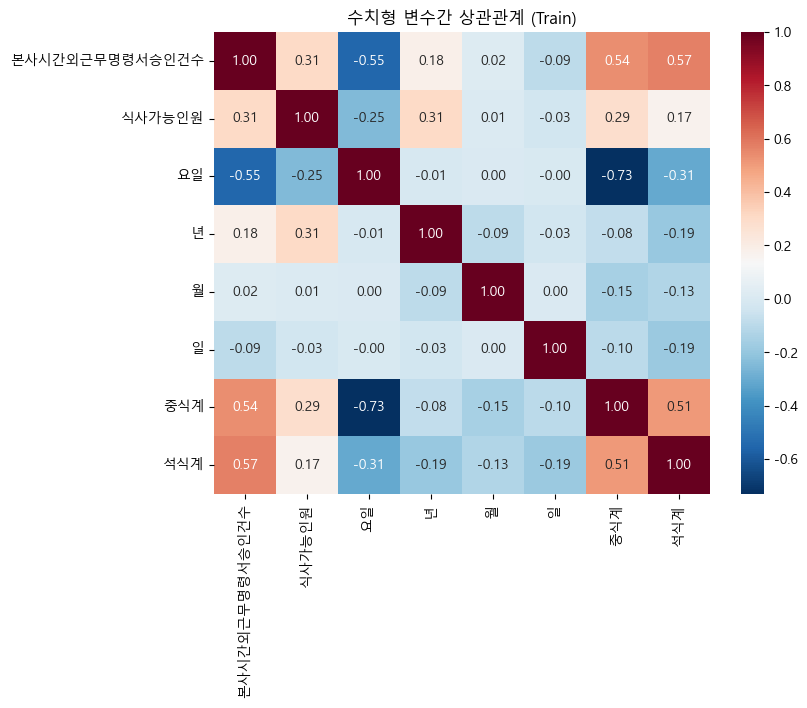

In [7]:
# 범주형 변수(요일) 인코딩 (Label Encoding 방식 적용 - 요일 순서를 반영)
day_dict = {'월': 0, '화': 1, '수': 2, '목': 3, '금': 4}
train['요일'] = train['요일'].map(day_dict)
test['요일'] = test['요일'].map(day_dict)

# 상관관계 시각화 (피처간 상관도)
corr_cols = ['본사시간외근무명령서승인건수', '식사가능인원', '요일', '년', '월', '일', '중식계', '석식계']
corr = train[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdBu_r', fmt='.2f')
plt.title('수치형 변수간 상관관계 (Train)')
plt.show()

요일은 중/석식에 강한 음의 상관관계가 있고(주후반일수록 감소), 식사가능인원은 중식계와 높은 양의 상관관계, 시간외근무명령서 승인건수는 석식계와 매우 높은 양의 상관관계를 가집니다.

## 4. 모델 생성 및 학습

기본적으로 메뉴 데이터 등 텍스트는 제외하고 숫자 및 날짜 정보로 LightGBM 모델을 훈련합니다.
최근 시계열 패턴을 반영하기 위해 시계열에 강점을 가지는 트리 모델 앙상블을 사용하며, Out-of-Fold나 TimeSeries Split을 사용할 수 있지만 여기서는 단순히 전체 데이터를 K-Fold하여 성능을 봅니다 (간단한 예시를 위해 편의상 KFold 적용).

In [8]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

features = ['요일', '본사정원수', '본사휴가자수', '본사출장자수', '본사시간외근무명령서승인건수', 
            '현본사소속재택근무자수', '년', '월', '일', '식사가능인원']

X_train = train[features]
y_train_lunch = train['중식계']
y_train_dinner = train['석식계']
X_test = test[features]

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 중식 모델
lunch_models = []
lunch_maes = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, y_tr = X_train.iloc[train_idx], y_train_lunch.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train_lunch.iloc[val_idx]
    
    model_lunch = LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1, learning_rate=0.05)
    model_lunch.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[])
    pred = model_lunch.predict(X_va)
    mae = mean_absolute_error(y_va, pred)
    lunch_models.append(model_lunch)
    lunch_maes.append(mae)

print(f"\n중식계 평균 MAE: {np.mean(lunch_maes):.4f}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000293 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1076
[LightGBM] [Info] Number of data points in the train set: 964, number of used features: 10
[LightGBM] [Info] Start training from score 890.409751
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1076
[LightGBM] [Info] Number of data points in the train set: 964, number of used features: 10
[LightGBM] [Info] Start training from score 884.246888
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1077
[LightGBM] [Info] Number of data points in the train set

In [9]:
# 석식 모델
dinner_models = []
dinner_maes = []

for train_idx, val_idx in kf.split(X_train):
    X_tr, y_tr = X_train.iloc[train_idx], y_train_dinner.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train_dinner.iloc[val_idx]
    
    model_dinner = LGBMRegressor(n_estimators=500, random_state=42, n_jobs=-1, learning_rate=0.05)
    model_dinner.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[])
    pred = model_dinner.predict(X_va)
    mae = mean_absolute_error(y_va, pred)
    dinner_models.append(model_dinner)
    dinner_maes.append(mae)

print(f"\n석식계 평균 MAE: {np.mean(dinner_maes):.4f}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000152 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1076
[LightGBM] [Info] Number of data points in the train set: 964, number of used features: 10
[LightGBM] [Info] Start training from score 461.356846
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000172 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1076
[LightGBM] [Info] Number of data points in the train set: 964, number of used features: 10
[LightGBM] [Info] Start training from score 459.927386
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000114 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1077
[LightGBM] [Info] Number of data points in the train set: 964, number of used features: 10
[LightGBM] [Info] Start train

## 5. 모델 평가 (Feature Importance) 및 예측

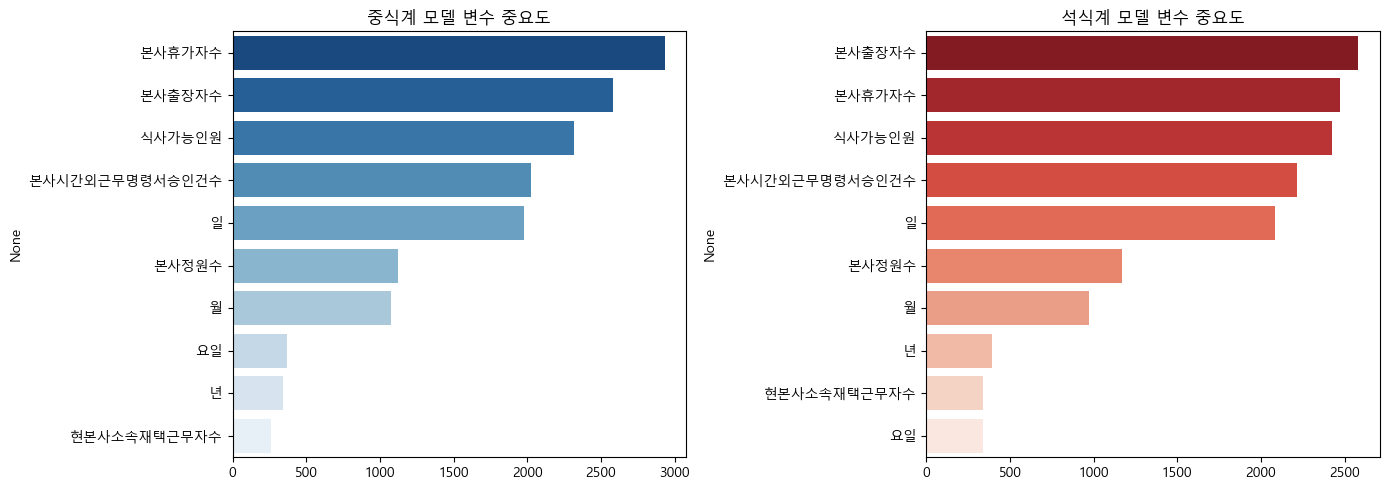

In [10]:
# Feature Importance 시각화 (첫 번째 폴드 모델 기준)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_imp_lunch = pd.Series(lunch_models[0].feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=feat_imp_lunch.values, y=feat_imp_lunch.index, ax=axes[0], palette='Blues_r')
axes[0].set_title('중식계 모델 변수 중요도')

feat_imp_dinner = pd.Series(dinner_models[0].feature_importances_, index=features).sort_values(ascending=False)
sns.barplot(x=feat_imp_dinner.values, y=feat_imp_dinner.index, ax=axes[1], palette='Reds_r')
axes[1].set_title('석식계 모델 변수 중요도')

plt.tight_layout()
plt.show()

In [11]:
# K-Fold 결과의 평균으로 예측
pred_lunch = np.zeros(len(X_test))
for model in lunch_models:
    pred_lunch += model.predict(X_test) / 5

pred_dinner = np.zeros(len(X_test))
for model in dinner_models:
    pred_dinner += model.predict(X_test) / 5

# 석식계 예측값 중 0 미만은 0으로 보정 (실제 0인 값이 있으므로 음수가 나올 수 없음)
pred_dinner = np.clip(pred_dinner, 0, None)

# submission 저장
submission['중식계'] = pred_lunch
submission['석식계'] = pred_dinner

display(submission.head())

submission.to_csv('dining_submission.csv', index=False)
print("예측 결과가 'dining_submission.csv'에 성공적으로 저장되었습니다.")

,일자,중식계,석식계
0,2021-01-27,1011.621679,185.159039
1,2021-01-28,957.622806,418.266494
2,2021-01-29,545.749259,275.997189
3,2021-02-01,1223.380272,540.481681
4,2021-02-02,989.834646,437.851657


예측 결과가 'dining_submission.csv'에 성공적으로 저장되었습니다.
